# Setup python session and notebook

In [196]:
import numpy as np
import pencil as pc
import matplotlib.pyplot as plt
import os
from utils import *
plt.rcParams['text.usetex'] = True

Evolution of the Chiral Chemical Potential $\mu_5$

The evolution equation for the chiral chemical potential $\mu_5$ can be written as:

\begin{equation}
\frac{\partial \mu_5}{\partial t} = \lambda_5 \mathbf{E} \cdot \mathbf{B} - \Gamma_{f5} \mu_5 + \text{S}_5
\end{equation}

where:

$\mu_5$ is the chiral chemical potential

$\lambda_5$ is the chiral anomaly coefficient

$\Gamma_{f5}$ is the chirality flipping rate (damping coefficient)

$\text{source}_5$ represents additional sources of chirality

In the code, $\mathbf{E} \cdot \mathbf{B}$ is computed as $\eta(\mathbf{j} \cdot \mathbf{B} - \mu_5 B^2)$, where $\eta$ is the resistivity and $\mathbf{j}$ is the current density.

Comments: Think about the length scales.


# Get simulation as object

In [197]:
SIMns = pc.get_sim('runs_directory2/no_source')
SIMnsmu0 = pc.get_sim('runs_directory2/no_source_mu0')
SIMss = pc.get_sim('runs_directory2/smooth_source')
SIMssmu0 = pc.get_sim('runs_directory2/smooth_source_mu0')
SIMss2 = pc.get_sim('runs_directory2/smooth_source2')
SIMss2mu0 = pc.get_sim('runs_directory2/smooth_source2_mu0')

? Warning: sim.dill in runs_directory2/no_source is not up to date, recreating simulation object..
? Warning: sim.dill in runs_directory2/no_source_mu0 is not up to date, recreating simulation object..
? Warning: sim.dill in runs_directory2/smooth_source is not up to date, recreating simulation object..
? Warning: sim.dill in runs_directory2/smooth_source_mu0 is not up to date, recreating simulation object..
? Warning: sim.dill in runs_directory2/smooth_source2 is not up to date, recreating simulation object..
? Warning: sim.dill in runs_directory2/smooth_source2_mu0 is not up to date, recreating simulation object..


## Read timeseries

In [198]:
tsns = pc.read.ts(file_name="time_series.dat",datadir=SIMns.datadir)
tsnsmu0 = pc.read.ts(file_name="time_series.dat",datadir=SIMnsmu0.datadir)
tsss = pc.read.ts(file_name="time_series.dat",datadir=SIMss.datadir)
tsssmu0 = pc.read.ts(file_name="time_series.dat",datadir=SIMssmu0.datadir)
tsss2 = pc.read.ts(file_name="time_series.dat",datadir=SIMss2.datadir)
tsss2mu0 = pc.read.ts(file_name="time_series.dat",datadir=SIMss2mu0.datadir)
tsall = [tsns,tsnsmu0,tsss,tsssmu0,tsss2,tsss2mu0]
labels = ['no_source',"nsmu0","smooth","smoothmu0","smooth2","smooth2mu0"]

Read 400 lines.
Invalid data on line 2. Skipping.
Invalid data on line 3. Skipping.
Invalid data on line 4. Skipping.
Invalid data on line 5. Skipping.
Invalid data on line 6. Skipping.
Invalid data on line 7. Skipping.
Invalid data on line 8. Skipping.
Invalid data on line 9. Skipping.
Invalid data on line 10. Skipping.
Invalid data on line 11. Skipping.
Invalid data on line 12. Skipping.
Invalid data on line 13. Skipping.
Invalid data on line 14. Skipping.
Invalid data on line 15. Skipping.
Invalid data on line 16. Skipping.
Invalid data on line 17. Skipping.
Invalid data on line 18. Skipping.
Invalid data on line 19. Skipping.
Invalid data on line 20. Skipping.
Invalid data on line 21. Skipping.
Invalid data on line 22. Skipping.
Invalid data on line 23. Skipping.
Invalid data on line 24. Skipping.
Invalid data on line 25. Skipping.
Invalid data on line 26. Skipping.
Invalid data on line 27. Skipping.
Invalid data on line 28. Skipping.
Invalid data on line 29. Skipping.
Invalid data

## Reading Power


In [199]:
params_ns = pc.read.param(datadir=SIMns.datadir,param2=True)
params_nsmu0 = pc.read.param(datadir=SIMnsmu0.datadir,param2=True)
params_ss = pc.read.param(datadir=SIMss.datadir,param2=True)
params_ssmu0 = pc.read.param(datadir=SIMssmu0.datadir,param2=True)
params_ss2 = pc.read.param(datadir=SIMss2.datadir,param2=True)
params_ss2mu0 = pc.read.param(datadir=SIMss2mu0.datadir,param2=True)

params_all = [params_ns,params_nsmu0,params_ss,params_ssmu0,params_ss2,params_ss2mu0 ]
labels = ['no_source',"nsmu0","smooth","smoothmu0","smooth2","smooth2mu0"]

In [ ]:
pwns = pc.read.power(datadir=SIMns.datadir)
pwnsmu0 = pc.read.power(datadir=SIMnsmu0.datadir)
pwss = pc.read.power(datadir=SIMss.datadir)
pwssmu0 = pc.read.power(datadir=SIMssmu0.datadir)
pwss2 = pc.read.power(datadir=SIMss2.datadir)
pwss2mu0 = pc.read.power(datadir=SIMss2mu0.datadir)

powers_all = [pwns,pwnsmu0,pwss,pwssmu0,pwss2,pwss2mu0]
powers_labels = ['no_source',"nsmu0","smooth","smoothmu0","smooth2","smooth2mu0"]

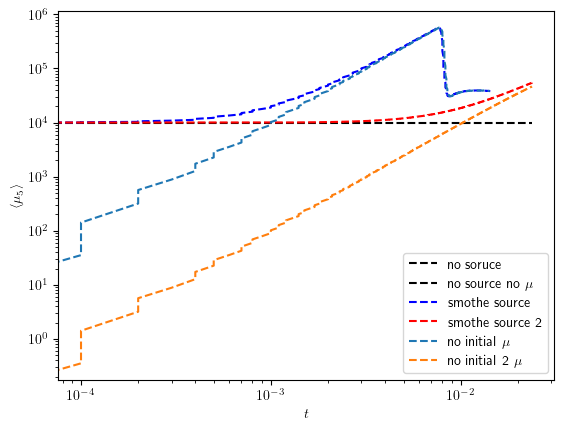

In [201]:
plt.loglog(tsns.t-1,tsns.mu5m,"--",color = "Black",label = "no soruce")
plt.loglog(tsnsmu0.t-1,tsnsmu0.mu5m,"--",color = "Black",label = r"no source no $\mu$")
plt.loglog(tsss.t-1,tsss.mu5m,"--",color = "Blue",label = "smothe source")
plt.loglog(tsss2.t-1,tsss2.mu5m,"--",color = "Red",label ="smothe source 2")
plt.loglog(tsssmu0.t-1,tsssmu0.mu5m,"--",label = r"no initial $\mu$")
plt.loglog(tsss2mu0.t-1,tsss2mu0.mu5m,"--",label = r"no initial 2 $\mu$")
plt.legend()
plt.xlabel(r"$t$")
plt.ylabel(r"$\langle \mu_5 \rangle $")
plt.show()

## Comperison of Mu vs S5

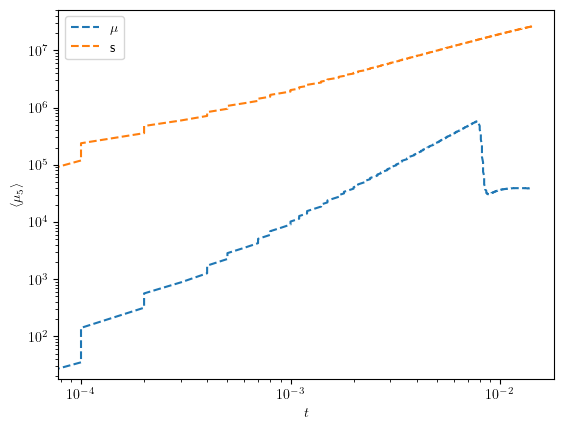

In [219]:
#plt.loglog(tsss.t-1,tsss.mu5m/10**4,"--",color = "Blue",label = "mu")
#plt.loglog(tsss.t-1,tsss.srce5m/10**7,"--",color = "Black",label = "S")

#plt.loglog(tsss2.t-1,tsss2.mu5m,"--",color = "Yellow",label ="mu 2")
#plt.loglog(tsss2.t-1,tsss2.srce5m/10,"--",color = "Red",label ="S 2")

plt.loglog(tsssmu0.t-1,tsssmu0.mu5m,"--",label = r"$\mu$")
plt.loglog(tsssmu0.t-1,tsssmu0.srce5m/10,"--",label = r"s")
#plt.loglog(tsss2mu0.t-1,tsss2mu0.mu5m,"--",label = r"no initial 2 $\mu$")
plt.legend()
plt.xlabel(r"$t$")
plt.ylabel(r"$\langle \mu_5 \rangle $")
plt.show()

In [203]:
# analitical calculation of source teram
y_values = (tsss2.t-1)/ params_ss2.source5_expt2* np.exp(-( tsss2.t -1)**2/(params_ss2.source5_expt2)**2)

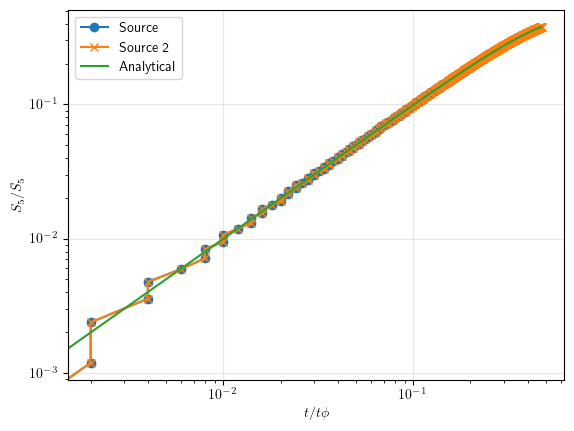

In [204]:
plt.loglog((tsss.t - 1)/params_ss.source5_expt2, tsss.srce5m / params_ss.source5,"-o", label=r"Source")

plt.loglog((tsss2.t - 1)/params_ss.source5_expt2, tsss2.srce5m / params_ss2.source5,"x-", label=r"Source 2")

plt.loglog((tsss2.t - 1)/params_ss.source5_expt2, y_values, label=r"Analytical")

plt.xlabel(r"$t/t{\phi}$")
plt.ylabel(r"$\displaystyle S_{5}/\bar{S}_{5}$")
plt.legend()
plt.grid(alpha=0.3)

# Reading parameters from the corespontid simulations

Here I will show all the paeremaeteres used in the conresponding simultatuon

In [205]:
#Sources parameters for all simulations
for id,sim in enumerate(params_all):
    print("____________________")
    print(f"key: {labels[id]}")
    print(f"source5: {params_all[id].source5:e}")
    print(f"source5_tdep: {params_all[id].source5_tdep}")
    print(f"source5_expt2: {params_all[id].source5_expt2}")
    print(f"gammaf5: {params_all[id].gammaf5:e}")
    print(f"t1_source5: {params_all[id].t1_source5}")
    print(f"t2_source5: {params_all[id].t2_source5}")
    print(f"Diffmu5: {params_all[id].diffmu5}")
    print(f"eta: {params_all[id].eta}")
    print(f"lambda: {getattr(params_all[id],"lambda5"):e}")
    print(f"nu: {params_all[id].nu}")
    print(f"tphi :{params_all[id].source5_expt2}")


____________________
key: no_source
source5: 0.000000e+00
source5_tdep: const
source5_expt2: 0.0500000007
gammaf5: 0.000000e+00
t1_source5: 0.0
t2_source5: 0.0
Diffmu5: 9.99999997e-07
eta: 9.99999997e-07
lambda: 2.500000e+09
nu: 4.99999987e-05
tphi :0.0500000007
____________________
key: nsmu0
source5: 0.000000e+00
source5_tdep: const
source5_expt2: 0.0500000007
gammaf5: 0.000000e+00
t1_source5: 0.0
t2_source5: 0.0
Diffmu5: 9.99999997e-07
eta: 9.99999997e-07
lambda: 2.500000e+09
nu: 4.99999987e-05
tphi :0.0500000007
____________________
key: smooth
source5: 1.000000e+09
source5_tdep: smooth_source
source5_expt2: 0.0500000007
gammaf5: 1.000000e+01
t1_source5: 1.0
t2_source5: 0.0
Diffmu5: 9.99999997e-07
eta: 9.99999997e-07
lambda: 2.500000e+09
nu: 4.99999987e-05
tphi :0.0500000007
____________________
key: smoothmu0
source5: 1.000000e+09
source5_tdep: smooth_source
source5_expt2: 0.0500000007
gammaf5: 1.000000e+01
t1_source5: 1.0
t2_source5: 0.0
Diffmu5: 9.99999997e-07
eta: 9.99999997e-0

## Generating power spectrum

### general test 

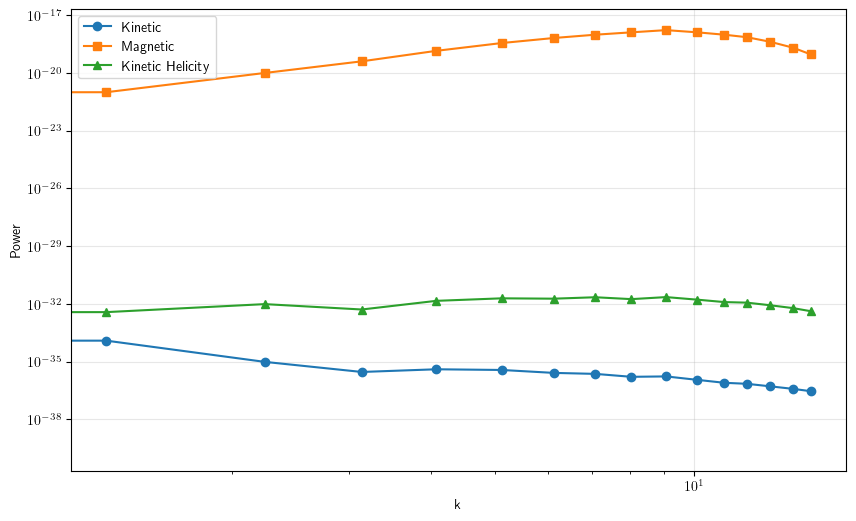

In [206]:
# Compare different types of spectra at the same time
plt.figure(figsize=(10, 6))

# Check if these spectra exist before plotting
if hasattr(pwns, 'kin'):
    plt.loglog(pwns.krms, pwns.kin[-1], 'o-', label='Kinetic')
if hasattr(pwns, 'mag'):
    plt.loglog(pwns.krms, pwns.mag[-1], 's-', label='Magnetic')
if hasattr(pwns, 'hel_kin'):
    plt.loglog(pwns.krms, np.abs(pwns.hel_kin[-1]), '^-', label='Kinetic Helicity')

plt.xlabel('k')
plt.ylabel('Power')
#plt.title(f'Different Power Spectra at t = {pwns.t[-1]:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Power for the simultations

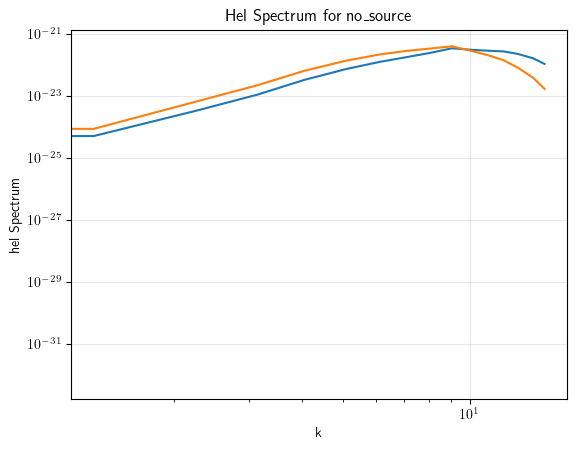

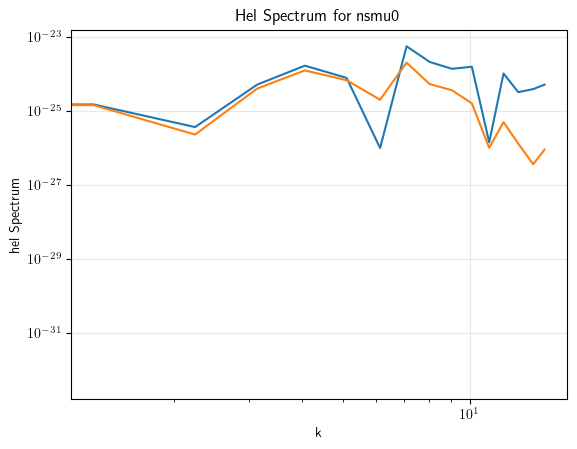

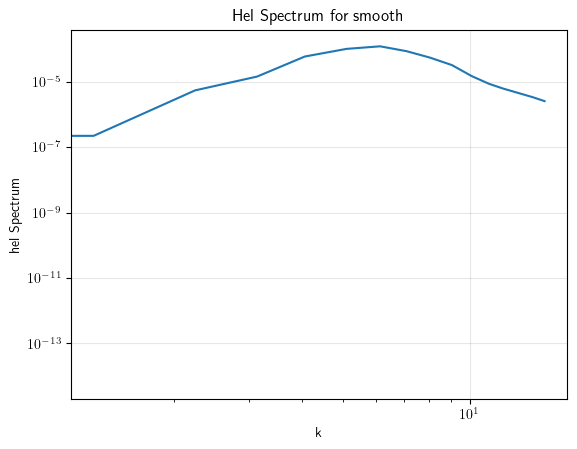

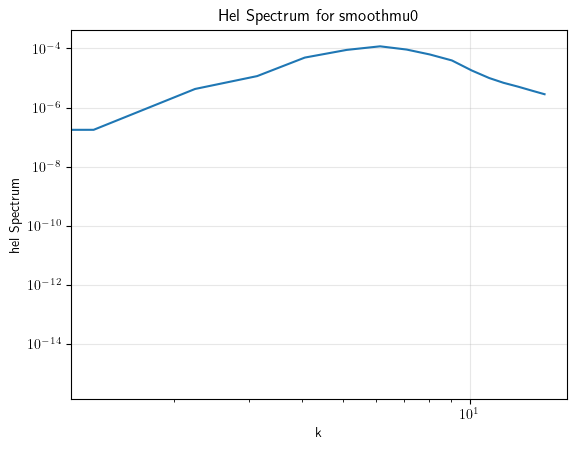

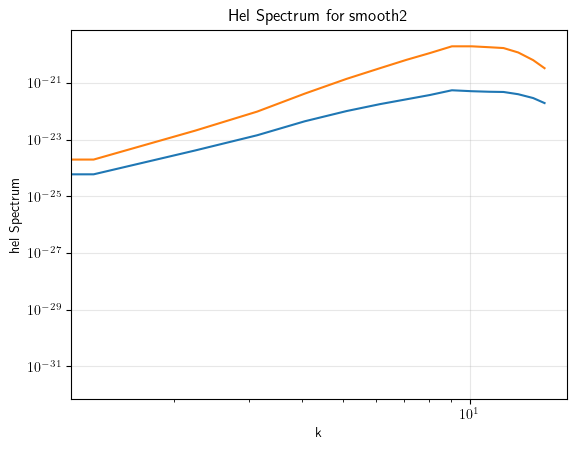

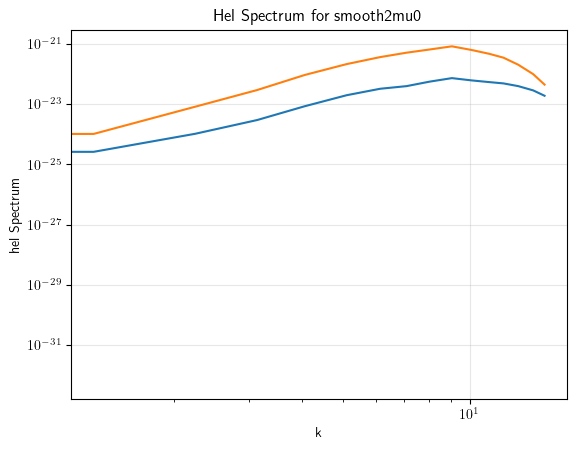

In [207]:
for id, sim in enumerate(powers_all):
    fig, ax = plt.subplots()
    times = range(len(sim.t))

    for idx in times:
        ax.loglog(sim.krms,
                  np.abs(sim.hel_mag[idx]),
                  label=f't = {sim.t[idx] - 1:.2f}')

    ax.set_xlabel('k')
    ax.set_ylabel('hel  Spectrum')
    ax.set_title(f'Hel Spectrum for {powers_labels[id]}')
    # ax.legend()#
    ax.grid(True, alpha=0.3)


    outfile = f"figs/hel_spectrum_{powers_labels[id]}.png"
    #fig.savefig(outfile, dpi=300, bbox_inches="tight")
    #plt.show()

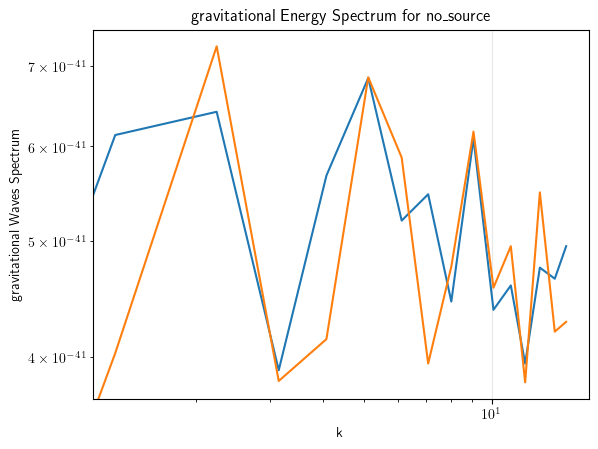

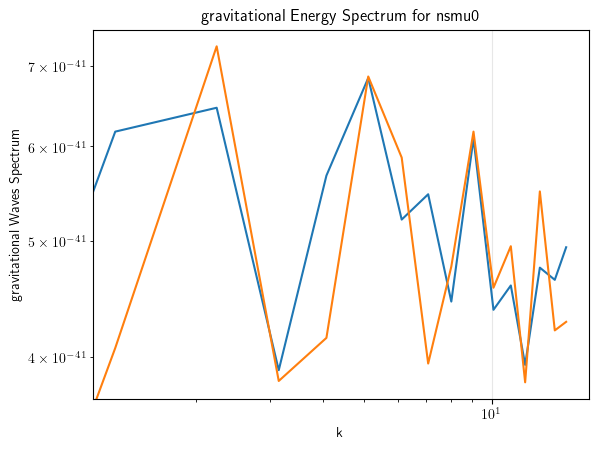

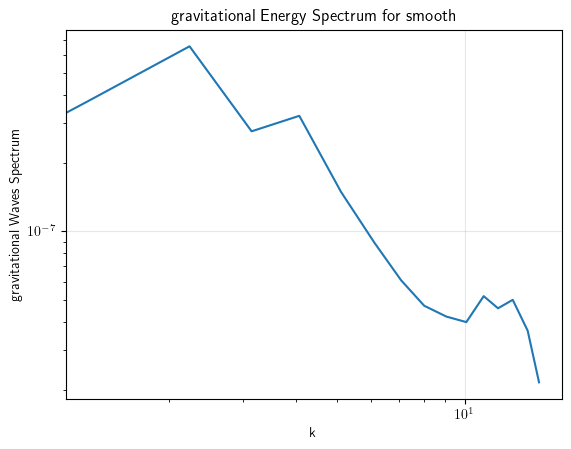

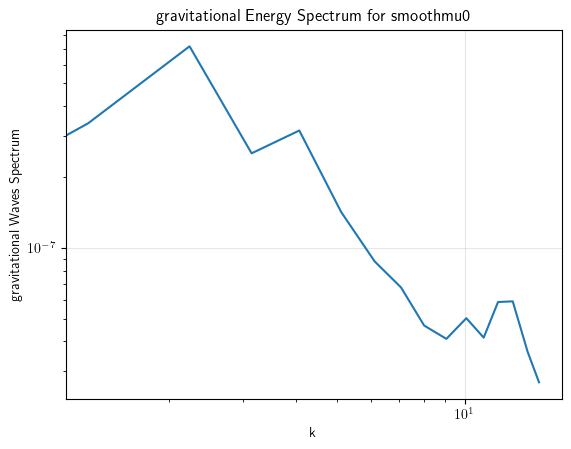

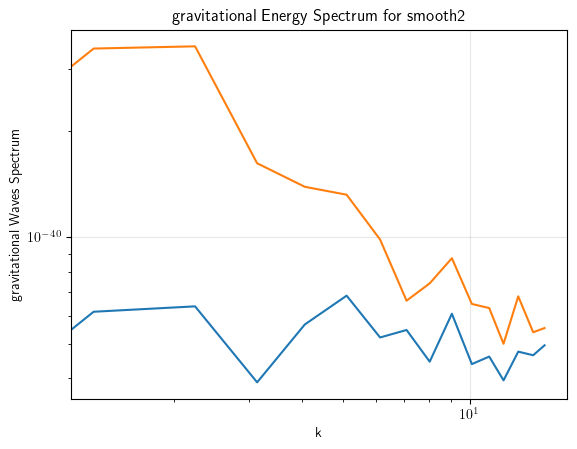

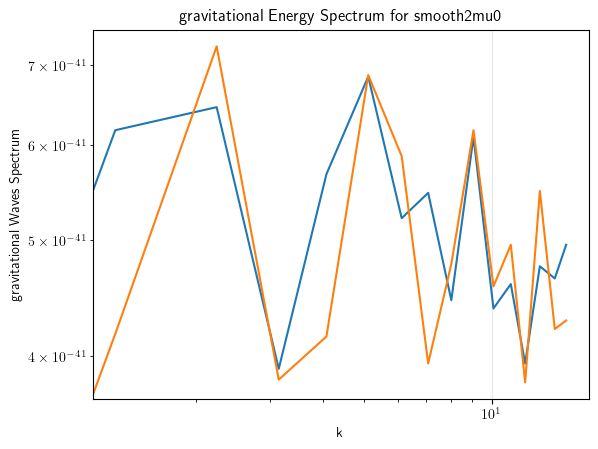

In [208]:
for id, sim in enumerate(powers_all):
    fig, ax = plt.subplots()
    times = range(len(sim.t))

    for idx in times:
        ax.loglog(sim.krms,
                  sim.GWs[idx],
                  label=f't = {sim.t[idx] - 1:.2f}')

    ax.set_xlabel('k')
    ax.set_ylabel('gravitational Waves Spectrum')
    ax.set_title(f'gravitational Energy Spectrum for {powers_labels[id]}')
    # ax.legend()#
    ax.grid(True, alpha=0.3)


    outfile = f"figs/gw_spectrum_{powers_labels[id]}.png"
    #fig.savefig(outfile, dpi=300, bbox_inches="tight")
    #plt.show()

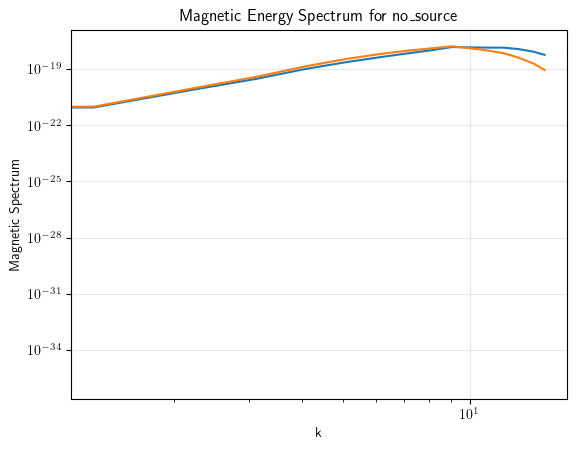

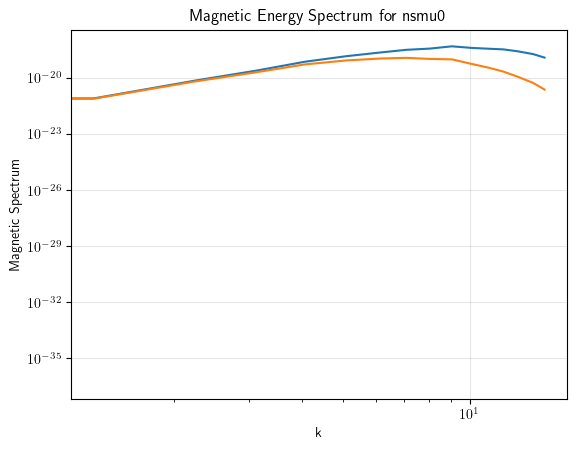

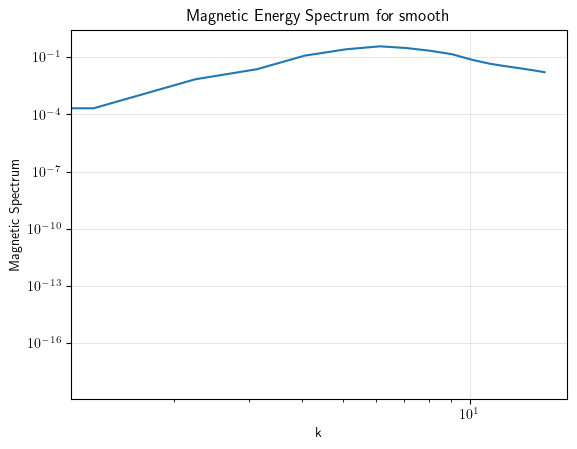

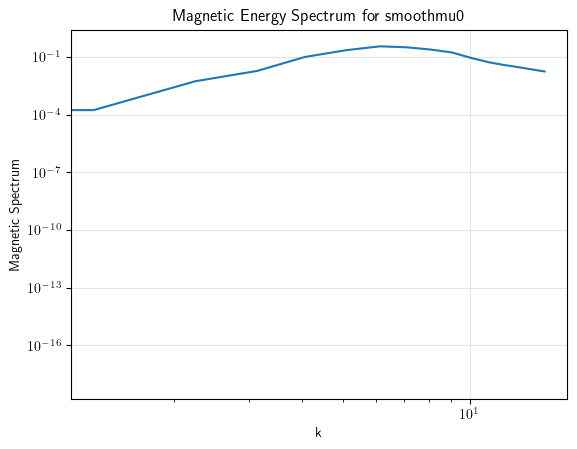

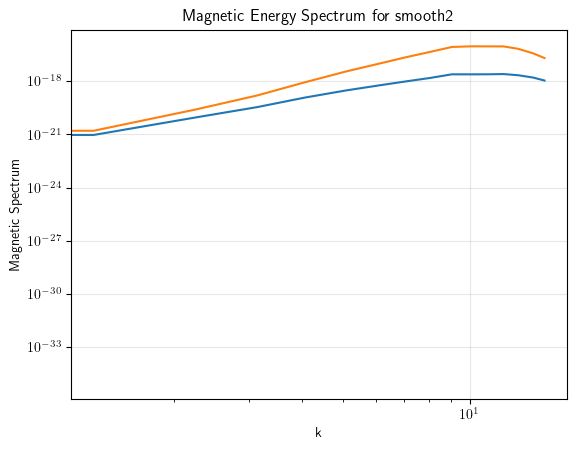

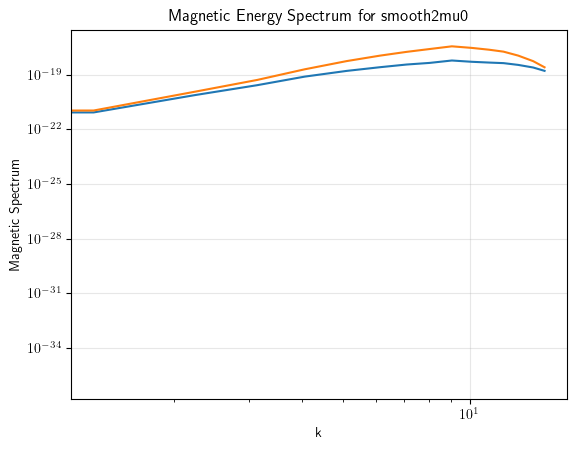

In [209]:
for id, sim in enumerate(powers_all):
    fig, ax = plt.subplots()
    times = range(len(sim.t))

    for idx in times:
        ax.loglog(sim.krms,
                  sim.mag[idx],
                  label=f't = {sim.t[idx] - 1:.2f}')

    ax.set_xlabel('k')
    ax.set_ylabel('Magnetic Spectrum')
    ax.set_title(f'Magnetic Energy Spectrum for {powers_labels[id]}')
    # ax.legend()
    ax.grid(True, alpha=0.3)


    outfile = f"figs/mag_spectrum_{powers_labels[id]}.png"
    #fig.savefig(outfile, dpi=300, bbox_inches="tight")
    #plt.show()

### Units

In [210]:
6 * 10 ** (-16)/55

1.090909090909091e-17

In [211]:
print(f"{2.5:,.0f}, {3.5:,.0f}, {4.5:,.0f}, {999.5:,.0f}")

2, 4, 4, 1,000
